In [26]:
# Import required libraries
import tensorflow as tf                      # Core machine learning framework
import tensorflow_datasets as tfds           # Contains public datasets for TensorFlow
import matplotlib.pyplot as plt              # For data visualization and plots

# Display TensorFlow version to confirm environment readiness
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


In [27]:
# Load the TensorFlow Flowers dataset

# 'as_supervised=True' means each element will be returned as (image, label)
# 'with_info=True' gives metadata about the dataset such as number of samples and class names
dataset, info = tfds.load('tf_flowers', as_supervised=True, with_info=True)

# Split the dataset into training (80%) and testing (20%)

# The original dataset has a single split called 'train', so we manually divide it
# .take() selects the first portion, .skip() skips that many examples for the remainder
train_ds = dataset['train'].take(int(0.8 * info.splits['train'].num_examples))
test_ds  = dataset['train'].skip(int(0.8 * info.splits['train'].num_examples))

# Print out dataset statistics to verify counts
print("Total images:", info.splits['train'].num_examples)
print("Training set size:", sum(1 for _ in train_ds))
print("Testing set size:", sum(1 for _ in test_ds))

Total images: 3670
Training set size: 2936
Testing set size: 734


In [28]:
# Normalise the image pixel values to range [0, 1]

# Neural networks train faster and more stably when pixel values are normalised
def normalize_img(image, label):
    # Convert image type from uint8 (0–255) to float32 (0–1)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Apply the normalisation function to both datasets
train_ds = train_ds.map(normalize_img)
test_ds  = test_ds.map(normalize_img)


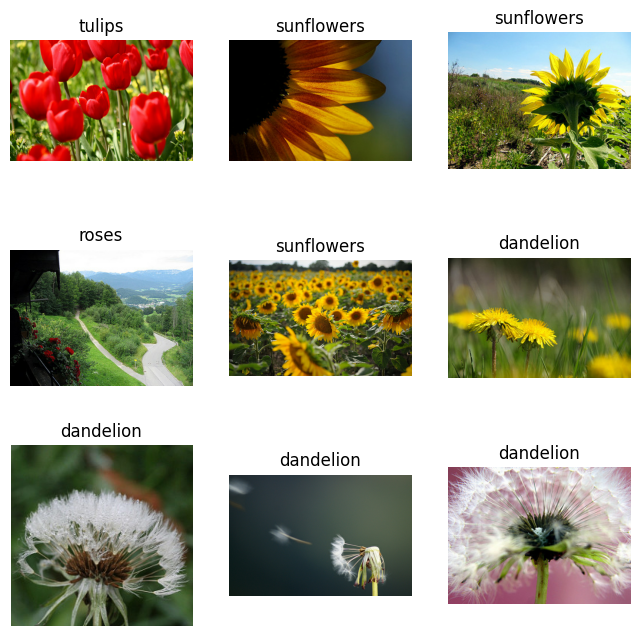

In [29]:
# Visualise a few sample images with their class labels

# This confirms the dataset has loaded correctly and that labels are mapped properly
plt.figure(figsize=(8,8))
for i, (image, label) in enumerate(train_ds.take(9)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(info.features['label'].int2str(label))  # Convert numeric label to class name
    plt.axis("off")                                   # Hide axes for cleaner view
plt.show()


In [30]:

import tensorflow as tf
import matplotlib.pyplot as plt


#Set standard image size and batch size

# All images in the dataset may have different dimensions.
# We resize them to a fixed size so that the CNN can process
# them uniformly. 180x180 is chosen for balance between
# accuracy and training speed.
IMG_SIZE = (180, 180)
BATCH_SIZE = 32

In [31]:

# Define a preprocessing function

# This function will resize each image to IMG_SIZE
# and return it along with its label.
def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    return image, label

# Apply the resizing operation to both training and testing sets
train_ds = train_ds.map(preprocess)
test_ds  = test_ds.map(preprocess)

In [32]:

# Apply batching, caching, and prefetching for efficiency

# .batch() groups images into sets of 32 so GPU can process
# multiple images at once.
# .cache() keeps images in memory after first load for faster reuse.
# .prefetch() loads the next batch while the current one is training.
train_ds = train_ds.batch(BATCH_SIZE).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds  = test_ds.batch(BATCH_SIZE).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print("Datasets prepared with batching, caching and prefetching.")
print(train_ds)

Datasets prepared with batching, caching and prefetching.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


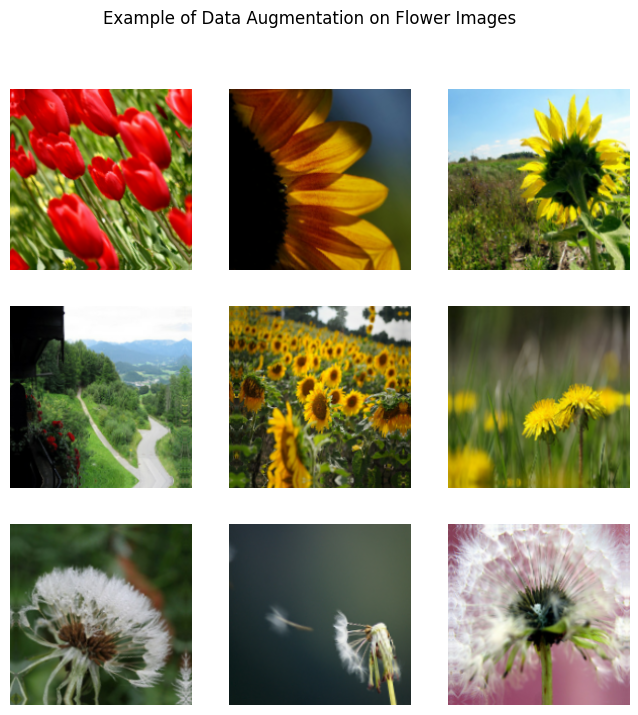

In [33]:
# An optional data augmentation pipeline

# Data augmentation helps the model generalize by showing
# slightly varied versions of the same image (flipped, rotated, etc.)
# during training.
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),    # randomly mirror images left/right
    tf.keras.layers.RandomRotation(0.1),         # randomly rotate by ±10%
    tf.keras.layers.RandomZoom(0.1)              # randomly zoom in/out by 10%
])

# Visualize how augmentation affects a few images
for images, labels in train_ds.take(1):
    plt.figure(figsize=(8, 8))
    for i in range(9):
        augmented_image = data_augmentation(images[i])
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image)
        plt.axis("off")
    plt.suptitle("Example of Data Augmentation on Flower Images")
    plt.show()
    break

In [34]:
# Import libraries and confirm TensorFlow version
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import plot_model
from IPython.display import Image

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,621 (25.36 MB)

 Trainable params: 6,647,621 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

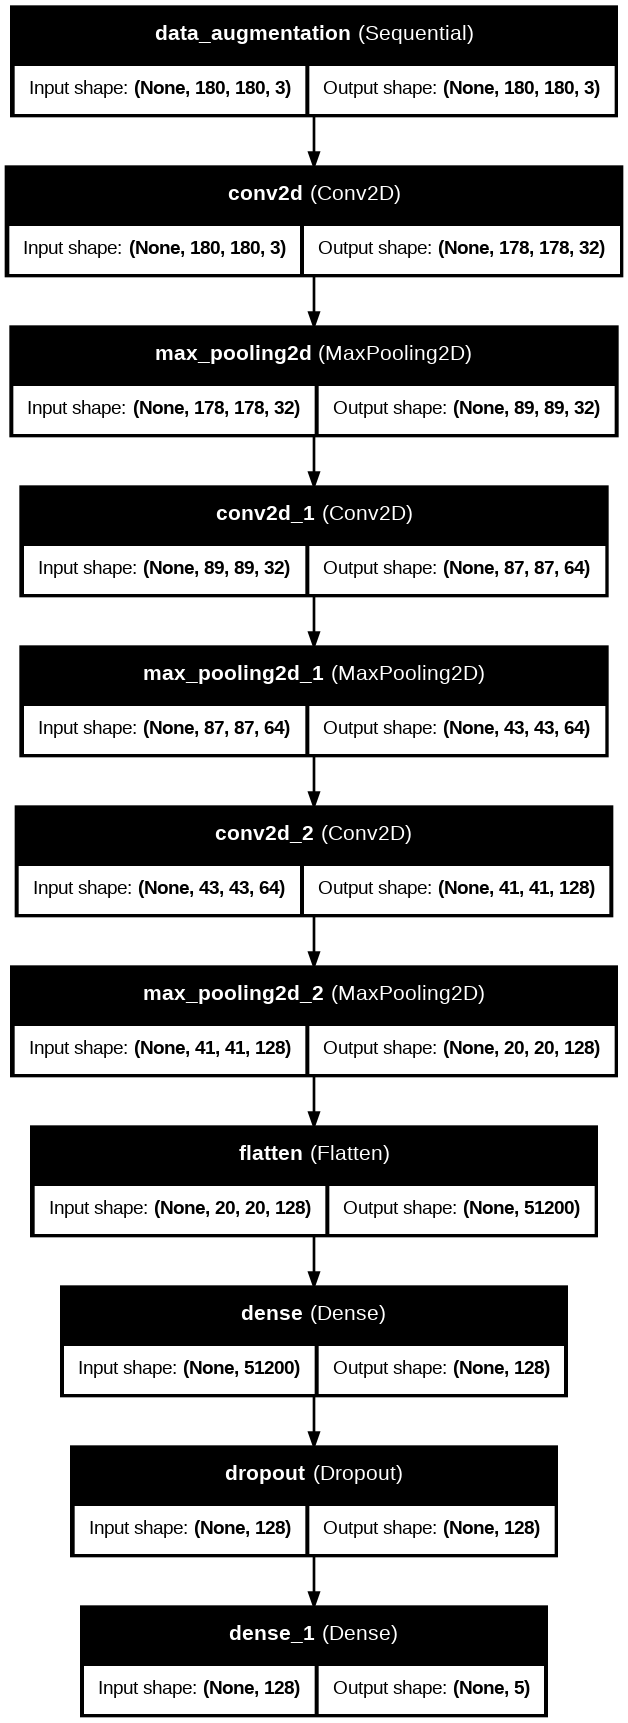

In [35]:
# Import required libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import plot_model
from IPython.display import Image

# Re-define the data augmentation pipeline
# These random transformations help prevent overfitting
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),   # randomly flips images left-right
    layers.RandomRotation(0.1),        # rotates images by ±10%
    layers.RandomZoom(0.1)             # zooms in/out slightly
], name="data_augmentation")

# Define the CNN architecture
# Sequential model means layers are executed in order
model = models.Sequential([
    layers.InputLayer(input_shape=(180,180,3)),   # declare input image size (180x180 RGB)
    data_augmentation,                            # apply augmentations during training

    layers.Conv2D(32, (3,3), activation='relu'),  # first conv layer: 32 filters
    layers.MaxPooling2D(2,2),                     # reduces image size to half

    layers.Conv2D(64, (3,3), activation='relu'),  # second conv layer: 64 filters
    layers.MaxPooling2D(2,2),                     # downsample again

    layers.Conv2D(128, (3,3), activation='relu'), # third conv layer: 128 filters
    layers.MaxPooling2D(2,2),                     # further reduce spatial size

    layers.Flatten(),                             # flatten 3D feature maps to 1D vector
    layers.Dense(128, activation='relu'),         # dense layer for learned representations
    layers.Dropout(0.3),                          # randomly disable 30% neurons to avoid overfitting
    layers.Dense(5, activation='softmax')         # output layer: 5 classes with probabilities
])

# Display model summary showing layers, output shapes, and parameter counts
model.summary()

# Compile the model
# Adam optimizer adjusts learning rate automatically
# SparseCategoricalCrossentropy is for integer-encoded labels
# Accuracy will be used as the main performance metric
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Visualize and export model architecture diagram
# This saves a PNG file and displays it directly in Colab
plot_model(
    model,
    to_file='cnn_architecture.png',
    show_shapes=True,        # show input/output shapes
    show_layer_names=True,   # show layer names
    dpi=96                   # image clarity
)

# Display the generated CNN architecture image
Image(filename='cnn_architecture.png')


In [36]:
# Import required libraries
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Create a small validation split from the training dataset
# This takes 10% of the training data for validation during training
val_size = int(0.1 * sum(1 for _ in train_ds.unbatch()))
train_size = int(0.9 * sum(1 for _ in train_ds.unbatch()))

# Rebuild the dataset to ensure proper split and shuffling
full_train = dataset['train'].map(lambda x, y: (tf.image.resize(tf.cast(x, tf.float32)/255.0, (180,180)), y))
train_ds = full_train.take(train_size).batch(32).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = full_train.skip(train_size).take(val_size).batch(32).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# Define callbacks for early stopping and best model saving
# EarlyStopping stops training if validation accuracy stops improving
# ModelCheckpoint saves the model weights whenever validation accuracy improves
early_stop = EarlyStopping(
    monitor='val_accuracy',      # watch validation accuracy
    patience=3,                  # stop if no improvement for 3 epochs
    restore_best_weights=True    # revert to best weights automatically
)

checkpoint = ModelCheckpoint(
    'best_model.h5',             # filename to save the best model
    monitor='val_accuracy',
    save_best_only=True,         # keep only the best-performing epoch
    verbose=1
)

# Train the model
# 'train_ds' is used for learning
# 'val_ds' is used for monitoring generalisation
# History will store accuracy and loss for both sets
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,                   # total maximum epochs
    callbacks=[early_stop, checkpoint],
    verbose=1                    # print training progress
)

# Print final training summary
print("\n✅ Model training completed.")
print(f"Best Validation Accuracy: {max(history.history['val_accuracy']):.4f}")


Epoch 1/20


KeyboardInterrupt: 

In [ ]:
# Import libraries for plotting
import matplotlib.pyplot as plt

# Retrieve training history
acc = history.history['accuracy']          # training accuracy per epoch
val_acc = history.history['val_accuracy']  # validation accuracy per epoch
loss = history.history['loss']             # training loss per epoch
val_loss = history.history['val_loss']     # validation loss per epoch
epochs_range = range(1, len(acc) + 1)      # x-axis values (epochs)

# Plot training vs validation accuracy
plt.figure(figsize=(8,5))
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Plot training vs validation loss
plt.figure(figsize=(8,5))
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


In [ ]:
# Instead of pulling labels from dataset features, define them manually
# Flower dataset has 5 fixed classes in alphabetical order
class_names = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

# Evaluate the best model (you already loaded it earlier)
test_loss, test_accuracy = best_model.evaluate(test_ds)
print(f"\nFinal Test Accuracy: {test_accuracy:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

# Get true and predicted labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred = np.argmax(best_model.predict(test_ds), axis=1)

# Confusion matrix and heatmap
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


In [ ]:
# Import necessary libraries
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Define the class names in order (same as training)
class_names = ['dandelion', 'daisy', 'tulip', 'sunflower', 'rose']

# Define a helper function to load, preprocess, and predict an image
def predict_flower(img_path):
    # Load the image and resize to match model input
    img = tf.keras.utils.load_img(img_path, target_size=(180, 180))

    # Convert image to array and normalize pixel values
    img_array = tf.keras.utils.img_to_array(img) / 255.0

    # Expand dimensions to simulate a batch (1, 180, 180, 3)
    img_batch = np.expand_dims(img_array, axis=0)

    # Predict using the trained model
    predictions = best_model.predict(img_batch)
    predicted_index = np.argmax(predictions)
    predicted_label = class_names[predicted_index]
    confidence = np.max(predictions) * 100

    # Display the image with predicted label
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_label} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

# Predict for your chosen images
predict_flower("/content/dandelion4.jpg")
predict_flower("/content/sunflower1.jpg")
predict_flower("/content/daisy.PNG")
predict_flower("/content/tulip.png")
predict_flower("/content/rose.png")



In [ ]:

# This feature visualizes the model's confidence (softmax probabilities)
# across all five flower classes for any user-selected image.
# It helps interpret how confident the model was in its final decision.

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Define flower class labels (must match dataset order)
class_names = ['dandelion', 'daisy', 'tulip', 'sunflower', 'rose']

# Function to preprocess and predict a single image with confidence chart
def predict_with_confidence(image_path):
    # Load image and resize to 180x180
    img = tf.keras.utils.load_img(image_path, target_size=(180, 180))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) / 255.0  # normalize and batch

    # Predict probabilities
    predictions = model.predict(img_array)
    confidence_scores = tf.nn.softmax(predictions[0]).numpy()

    # Identify top class and its probability
    top_idx = np.argmax(confidence_scores)
    top_label = class_names[top_idx]
    top_conf = confidence_scores[top_idx] * 100

    # Display image with predicted label
    plt.figure(figsize=(6,6))
    plt.imshow(tf.keras.utils.load_img(image_path))
    plt.title(f"Predicted: {top_label} ({top_conf:.2f}%)")
    plt.axis("off")
    plt.show()

    # Display confidence bar chart
    plt.figure(figsize=(6,4))
    plt.bar(class_names, confidence_scores, color='skyblue')
    plt.title("Model Confidence for Each Class")
    plt.ylabel("Probability")
    plt.ylim(0, 1)
    plt.show()

# Example usage: run this function on any test image path
predict_with_confidence("/content/dandelion4.jpg")
